Running simulation with: T = 8, dt = 0.02, nr = 1, a = tensor([3.]), b = tensor([5.]), c = tensor([4.]), d = tensor([3.]), P = tensor([1.]), Q = tensor([1.]), tauE = tensor([1.]), tauI = tensor([2.]), nr = 1


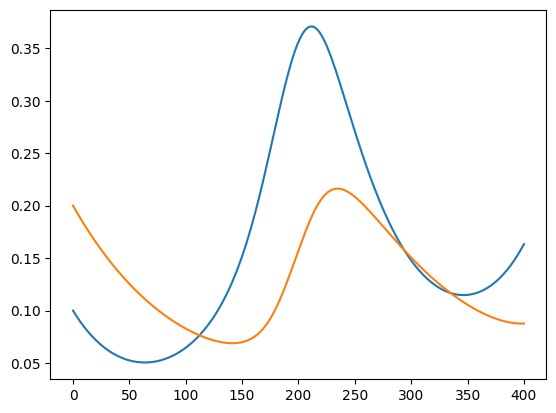

Iteration 0 14:08:26
Parameter p(a)_r0 [n = 1, mu=tensor([[0.]]), cov=tensor([[100.]])]
Parameter p(b)_r0 [n = 1, mu=tensor([[0.]]), cov=tensor([[100.]])]
Parameter p(c)_r0 [n = 1, mu=tensor([[0.]]), cov=tensor([[100.]])]
Parameter p(d)_r0 [n = 1, mu=tensor([[0.]]), cov=tensor([[100.]])]
------
Iteration 1 14:08:28
Parameter p(a)_r0 [n = 1, mu=tensor([[0.1086]]), cov=tensor([[2.1654]])]
Parameter p(b)_r0 [n = 1, mu=tensor([[1.3171]]), cov=tensor([[3.8846]])]
Parameter p(c)_r0 [n = 1, mu=tensor([[2.6465]]), cov=tensor([[65.6160]])]
Parameter p(d)_r0 [n = 1, mu=tensor([[-1.5435]]), cov=tensor([[77.9314]])]
------
Iteration 2 14:08:31
Parameter p(a)_r0 [n = 1, mu=tensor([[0.6894]]), cov=tensor([[1.0115]])]
Parameter p(b)_r0 [n = 1, mu=tensor([[1.0968]]), cov=tensor([[1.9083]])]
Parameter p(c)_r0 [n = 1, mu=tensor([[1.7469]]), cov=tensor([[3.8844]])]
Parameter p(d)_r0 [n = 1, mu=tensor([[0.0152]]), cov=tensor([[10.7263]])]
------
Iteration 3 14:08:33
Parameter p(a)_r0 [n = 1, mu=tensor([[0

In [1]:
from fg.variables import Variable, Parameter
from fg.factors import DynamicsFactor, ObservationFactor, PriorFactor, MLPFactor
from fg.simulation_config import simulate_wc
from fg.graph import Graph
from fg.gaussian import Gaussian
import torch
import matplotlib.pyplot as plt
from datetime import datetime
import random

sigma_obs = 1e-2
sigma_dynamics = 1e-3
sigma_prior = 1e1
iters = 150
T = 8
nr = 1
dt = 0.02

nn_weights = 7

C = torch.empty((nr, nr)).normal_(0.2, 0.1)
C.fill_diagonal_(0.)

config = {
    'T': T,
    'dt': dt,
    'nr': nr,
    'C': C,
    'a': torch.empty((nr,)).normal_(3., 0.),
    'b': torch.empty((nr,)).normal_(5., 0.),
    'c': torch.empty((nr,)).normal_(4., 0.),
    'd': torch.empty((nr,)).normal_(3., 0.),
    'P': torch.empty((nr,)).normal_(1., 0.),
    'Q': torch.empty((nr,)).normal_(1., 0.),
    'dyn_noise': False
}

E, I = simulate_wc(config)
time = torch.arange(0, len(E), 1)
plt.plot(E)
plt.plot(I)
plt.show()

factor_graph = Graph(nr)

param_list = ['a', 'b', 'c', 'd']
nn_params = [f'w{i}' for i in range(nn_weights)]

# Construct FG
for t in range(len(time)):
    for r in range(nr):
        factor_graph.var_nodes[f'osc_t{t}_r{r}'] = Variable(
            id       = f'osc_t{t}_r{r}',
            belief   = Gaussian(torch.tensor([[0.1, 0.1]]).T, torch.tensor([[0.2, 0.], [0., 0.2]])),
            graph    = factor_graph, 
            num_vars = 2,
            connected_factors = [(f'osc_t{t}_r{r}', f'osc_t{t+1}_r{r}') if t+1 < len(time) else -1] +  [(f'osc_t{t-1}_r{r}', f'osc_t{t}_r{r}') if t > 0 else -1] 
        )

        factor_graph.factor_nodes[f'o_t{t}_r{r}'] = ObservationFactor(
            factor_id = f'o_t{t}_r{r}', 
            var_id    = f'osc_t{t}_r{r}',
            z         = torch.tensor([[E[t, r], I[t,r]]]).T.float(),
            lmbda_in  = torch.tensor([[sigma_obs ** -2, 0.], [0., sigma_obs ** -2]]),
            graph     = factor_graph
        )

        # if t < len(time)-1:
        #     factor_graph.factor_nodes[f'nn_factor_t{t}_r{r}'] = MLPFactor(
        #         factor_id = f'nn_factor_t{t}_r{r}',
        #         var_id = f'nn_var_t{t}_r{r}',
        #         St_id = f'osc_t{t}_r{r}',
        #         lmbda_in = torch.tensor([[1e0 ** -2, 0.], [0., 1e0 ** -2]]),
        #         graph = factor_graph,
        #         param_ids = nn_params
        #     )

# Add WC parameters to each region
for index, p in enumerate(param_list):
    for r in range(nr):
        p_id = f'p({p})_r{r}'

        factor_graph.param_ids.append(p_id)      
        factor_graph.var_nodes[p_id] = Parameter(
            id     = p_id, 
            belief = Gaussian(torch.tensor([[0.]]), torch.tensor([[sigma_prior ** 2.]])),
            graph  = factor_graph,
            connected_factors = [(f'osc_t{t}_r{r}', f'osc_t{t+1}_r{r}') for t in range(len(time)-1)]
        )

        factor_graph.factor_nodes[f'p_prior_p{p}_r{r}'] = PriorFactor(
            factor_id = f'p_prior_p{p}_r{r}',
            var_id = p_id,
            z = torch.tensor([[0.]]).T,
            lmbda_in = torch.diag(torch.tensor([sigma_prior ** -2.])),
            graph = factor_graph
        ) 

# # Add the neural network params
# for i in range(len(nn_params)):
#     factor_graph.var_nodes[f'w{i}'] = Parameter(
#         id     = f'w{i}', 
#         belief = Gaussian(torch.tensor([[0.]]), torch.tensor([[sigma_prior ** 2.]])),
#         graph  = factor_graph,
#         connected_factors = [f'nn_factor_t{t}_r{r}' for t in range(len(time)-1) for r in range(nr)]
#     )

#     factor_graph.factor_nodes[f'w{i}_prior'] = PriorFactor(
#         factor_id = f'w{i}_prior',
#         var_id = f'w{i}',
#         z = torch.tensor([[1e-1]]),
#         lmbda_in = torch.tensor([[sigma_prior ** -2.]]),
#         graph = factor_graph 
#     )

#     factor_graph.param_ids.append(f'w{i}')


# Add the dynamics factors between timesteps in every region
for r in range(nr):
    for t in range(len(time)):
        if t+1 < len(time):
            dyn_id = (f'osc_t{t}_r{r}', f'osc_t{t+1}_r{r}')
            factor_graph.factor_nodes[dyn_id] = DynamicsFactor(
                Vt_id  = f'osc_t{t}_r{r}',
                Vtp_id = f'osc_t{t+1}_r{r}',
                region_id = r,
                conn = C,
                lmbda_in = torch.tensor([[sigma_dynamics ** -2, 0.], [0., sigma_dynamics ** -2]]),
                factor_id = dyn_id, 
                graph = factor_graph,
                connected_params = [f'p({p})_r{r}' for p in param_list]
            )

            # # This is the NNt variable
            # factor_graph.var_nodes[f'nn_var_t{t}_r{r}'] = Variable(
            #     id = f'nn_var_t{t}_r{r}',
            #     belief = Gaussian(torch.tensor([[0., 0.]]).T, torch.tensor([[100., 0.], [0., 100.]])),
            #     graph = factor_graph,
            #     num_vars = 2,
            #     connected_factors = [f'nn_factor_t{t}_r{r}', dyn_id]
            # )

            # # Add a narrow prior to the NNt variable
            # factor_graph.factor_nodes[f'nn_prior_t{t}_r{r}'] = PriorFactor(
            #     factor_id = f'nn_prior_t{t}_r{r}',
            #     var_id = f'nn_var_t{t}_r{r}',
            #     z = torch.tensor([[1e-2, 1e-2]]).T,
            #     lmbda_in = torch.tensor([[1e-1 ** -2., 0.], [0., 1e-1 ** -2.]]),
            #     graph = factor_graph 
            # )
    
# START GBP
for iter in range(iters):
    print(f'Iteration {iter} {datetime.now().hour:02d}:{datetime.now().minute:02d}:{datetime.now().second:02d}')
    for a in param_list:
        for r in range(nr):
            print(factor_graph.var_nodes[f'p({a})_r{r}'])

            if factor_graph.var_nodes[f'p({a})_r{r}'].belief.eta.isnan().any(): 
                exit(0)
    
    # for w in nn_params:
    #     print(factor_graph.var_nodes[w])
    
    print('------')

    if iter == 0:
        factor_graph.update_all_observational_factors()

        for i in factor_graph.param_ids:
            curr = factor_graph.var_nodes[i]
            curr.compute_and_send_messages()

        factor_graph.prune()

    var_nodes = [(t, r) for t in range(len(time)) for r in range(nr)]
    random.shuffle(var_nodes)

    for t, r in var_nodes:
        curr = factor_graph.var_nodes[f'osc_t{t}_r{r}']
        curr.compute_and_send_messages()

        if t+1 < len(time):
            # factor_graph.var_nodes[f'nn_var_t{t}_r{r}'].compute_and_send_messages()
            # curr = factor_graph.factor_nodes[f'nn_factor_t{t}_r{r}']
            curr.compute_and_send_messages()
    
    factor_nodes = [(t, r) for t in range(len(time)-1) for r in range(nr)]
    random.shuffle(factor_nodes)
    
    for t, r in factor_nodes:
        factor_graph.factor_nodes[(f'osc_t{t}_r{r}', f'osc_t{t+1}_r{r}')].compute_and_send_messages()
    
    # # Update parameters after each complete iteration
    factor_graph.update_params()

In [ ]:
factor_graph.update_all_observational_factors()
factor_graph.prune()
# for i in factor_graph.param_ids: factor_graph.var_nodes[i].compute_and_send_messages()
for i in factor_graph.var_nodes.keys(): factor_graph.var_nodes[i].compute_and_send_messages()

In [ ]:
factor_graph.factor_nodes['osc_t2_r0', 'osc_t3_r0']._compute_message_to_i(5).cov

In [ ]:
# TOY EXAMPLE OF LINEARISATION IN THE MLP FACTOR
from torch.nn.functional import linear, leaky_relu, relu

def reshape_mlp_params(all_args, a, b):
    dim = a * b + b
    args = all_args[:dim]

    weights = torch.cat([arg.view(-1) for arg in args[:a*b]], dim=0).view(b, a)    
    biases = torch.cat([arg.view(-1) for arg in args[a*b:]], dim=0)

    return weights, biases, all_args[dim:]

def h(Et, It, *weights):
    St = torch.tensor([[Et, It]])

    layer_sizes = [2,4,4,4,2]

    for l in range(len(layer_sizes)-1):
        w, b, weights = reshape_mlp_params(weights, layer_sizes[l], layer_sizes[l+1])
        St = linear(St, w, b)

        if l < len(layer_sizes)-2: St = leaky_relu(St)

    return St

weights = [torch.tensor([[0.5]]) for _ in range(62)]
Et, It = torch.tensor([[0.1]]), torch.tensor([[0.2]])

torch.concat(torch.autograd.functional.jacobian(h, (Et, It, *weights)), 0)[..., 0, 0]